# Limitations of K-means clustering 

- Assumes convex/spherical clusters  
    - Example: two-moons or concentric circles — K-means will split shapes incorrectly because it partitions by centriods which is mean based   
   
- Sensitive to cluster size and density  
    - Example: a small dense cluster next to a large sparse one — centroids tend to favor the larger mass and can swallow the small cluster.  
   

- Sensitive to outliers  
    - Example: a single distant point can pull a centroid toward it and distort a whole cluster.  
    

- Must choose K (number of clusters) a priori  
    - Example: picking K too large splits natural clusters; too small forces unrelated groups together.  

Limitations of K-means clustering


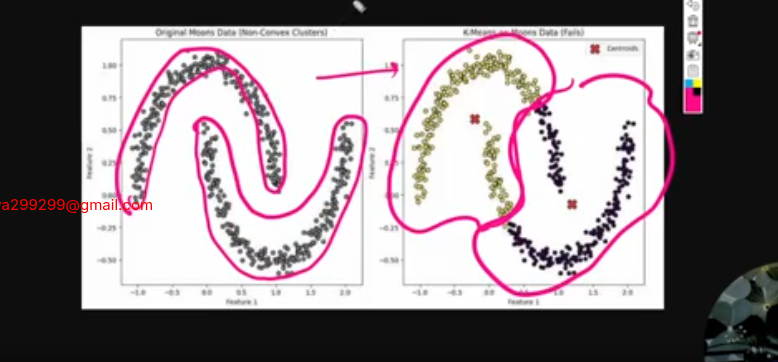

In [4]:
from IPython.display import Image, display

print("Limitations of K-means clustering")
display(Image(filename='K-means-clustering-limitation.png'))



# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

#### - Density-based clustering algorithm: groups points that are closely packed and marks low-density points as noise.

###  - Pros:
    - Finds arbitrarily shaped clusters
    - Robust to outliers (labels them as noise)
    - No need to pre-specify number of clusters (k)
    -works well with sperical and non-spherical data 



In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import  StandardScaler


from sklearn.datasets import make_moons # for generating synthetic data
                                         # (make_circles , make_blobs, make_regression, make_s_curve)
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans

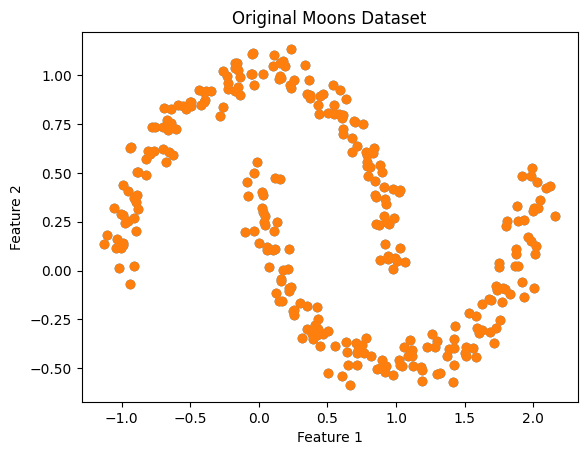

In [16]:
X, y = make_moons(n_samples = 300 , noise = 0.06 , random_state= 42)

# n_sample =300 , totoal 300 points will be generated
# noise ->outliners will be generated
# random_state ->  for reproducibility of the results

plt.scatter(X[:,0] ,X[:,1])   # selecting all rows and 0th column and 1st column

plt.scatter(X[:,0] , X[:,1])
plt.title('Original Moons Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()




In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # scaling since dbscan is diatance based 

In [ ]:
dbscan = DBSCAN(eps = 0.3 , min_samples = 4)

In [31]:
dbscan.fit(X_scaled)

labels= dbscan.labels_

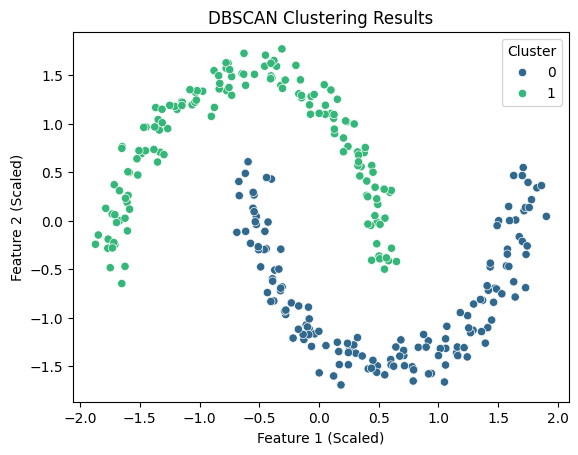

In [32]:
sns.scatterplot(x = X_scaled[: ,0] , y =X_scaled[: ,1] , hue = labels ,palette = 'viridis' )
plt.title('DBSCAN Clustering Results')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.legend(title='Cluster')
plt.show()

### CComponents of DBSCAN
#### - Epsilon (eps): maximum distance between two samples for them to be considered as in the same neighborhood/ cluster ( radious) 
#### - MinPts: minimum number of points required to form a dense region (cluster).

#### 3 types of data 
#### 1. core point ( the most central point in a cluster)
#### 2. border point ( points that are on the edge of a cluster)
#### 3. noise point ( points that are not part of any cluster)

### ***Densely connected points***

#### **Core points** that are reachable from each other in the same cluster -> together form a dense / bigger cluster.

Densely connected points in DBSCAN


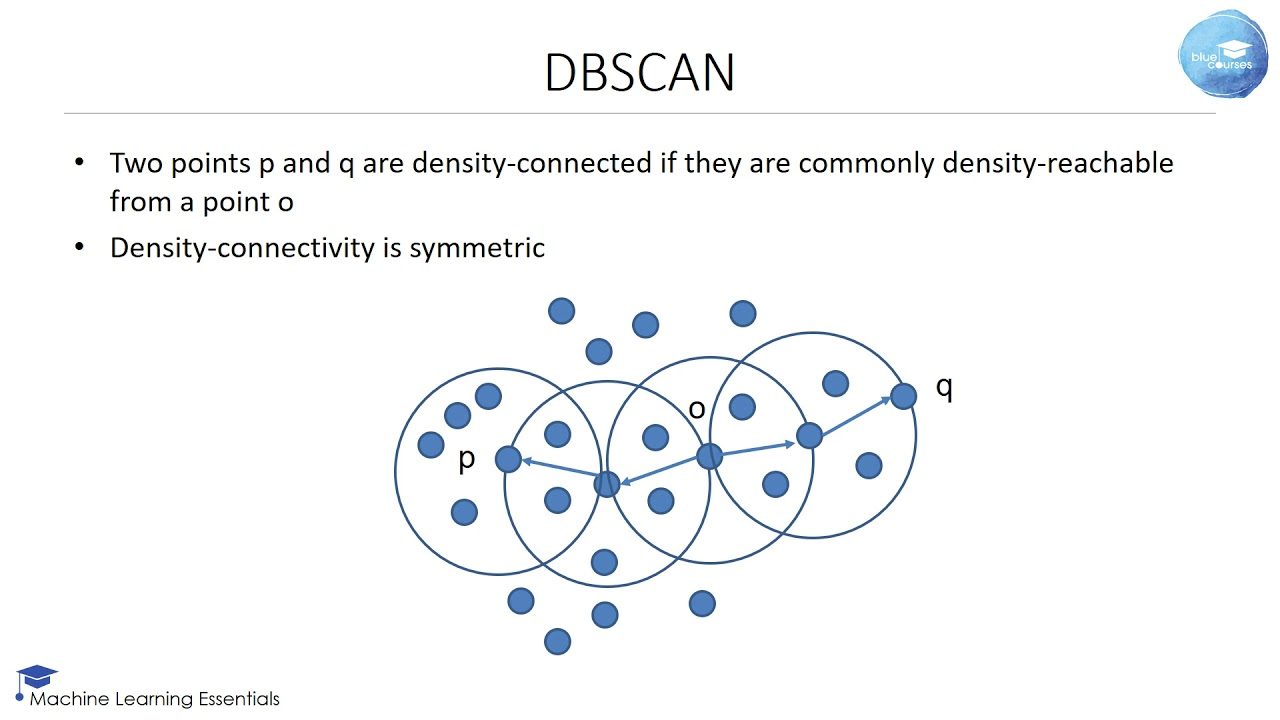

In [8]:
from IPython.display import Image, display

print("Densely connected points in DBSCAN")
display(Image(filename='densely_connected_Points.jpg'))



### for visulaization visit https://www.naftaliharris.com/blog/visualizing-dbscan-clustering/

## DBSCAN steps

1. For each point, find all neighbors within distance `eps`.
2. If it has ≥ `MinPts` neighbors, mark it as a **core point** and start a new cluster.
3. If it has fewer, mark it as **border** (near a core point) or **noise**.
4. Expand the cluster by pulling in all points reachable from core points.
5. Repeat until every point is clustered or marked noise.